# Wine Origin Classification using ANN
### Multivariate Data Analysis (CH5044) — Assignment 1
**Dataset:** UCI Wine Dataset — 178 samples, 13 features, 3 winery classes  
**Task:** Classify wines by origin using Artificial Neural Network  
**Reference:** MATLAB nprtool equivalent in Python (sklearn MLPClassifier)
---

## 1. Install & Import

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score,
                             RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

## 2. Load & Understand Data
Dataset has 13 features and 3 one-hot encoded target columns (Wine-Class-1, 2, 3).  
178 observations, zero nulls, no categorical features — all numeric.

In [31]:
df = pd.read_csv('Wine-Classification.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Nulls:", df.isnull().sum().sum())
print()
df.head()

Shape: (178, 16)
Columns: ['Alcohol', 'Malic acid', 'Ash', 'alkalinity of ash', 'Mg', 'total phenols', 'flavonoids', 'Nonflavonoid phenols', 'Proanthocyanidins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline', 'Wine-Class-1', 'Wine-Class-2', 'Wine-Class-3']
Nulls: 0



,Alcohol,Malic acid,Ash,alkalinity of ash,Mg,total phenols,flavonoids,Nonflavonoid phenols,Proanthocyanidins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,Wine-Class-1,Wine-Class-2,Wine-Class-3
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1,0,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1,0,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1,0,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1,0,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1,0,0


In [32]:
# target is one-hot encoded — reconstruct single class label
target_cols = ['Wine-Class-1', 'Wine-Class-2', 'Wine-Class-3']
X = df.drop(columns=target_cols)
y = df[target_cols].values.argmax(axis=1) + 1   # 1, 2, 3

print("Feature matrix (X):", X.shape)
print("Target vector (y):", y.shape)
print()
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index())
# 3 wineries — class 1: 59, class 2: 71, class 3: 48

Feature matrix (X): (178, 13)
Target vector (y): (178,)

Class distribution:
1    59
2    71
3    48
Name: count, dtype: int64


## 3. Exploratory Data Analysis

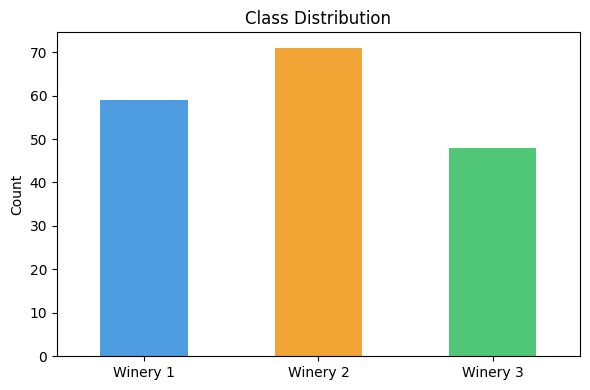

In [33]:
# class distribution
plt.figure(figsize=(6, 4))
pd.Series(y).value_counts().sort_index().plot(
    kind='bar', color=['#4e9de0','#f1a535','#50c878'])
plt.xticks([0,1,2], ['Winery 1','Winery 2','Winery 3'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

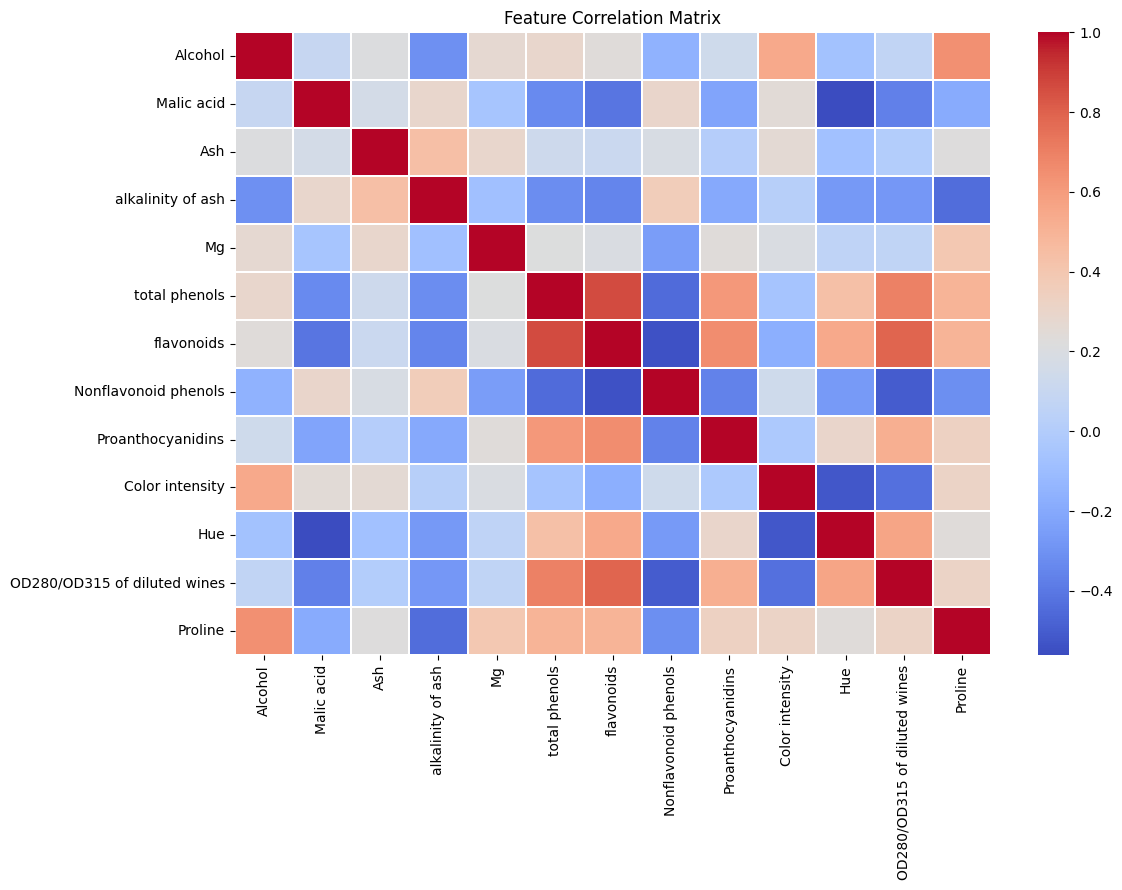

In [34]:
# feature correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False, linewidths=0.3)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [35]:
# correlation of features with class label
corr_with_y = pd.DataFrame(X.values, columns=X.columns)
corr_with_y['Class'] = y
corr_target = corr_with_y.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Feature correlation with class label:")
print(corr_target)

Feature correlation with class label:
flavonoids                     -0.847498
OD280/OD315 of diluted wines   -0.788230
total phenols                  -0.719163
Proline                        -0.633717
Hue                            -0.617369
alkalinity of ash               0.517859
Proanthocyanidins              -0.499130
Nonflavonoid phenols            0.489109
Malic acid                      0.437776
Alcohol                        -0.328222
Color intensity                 0.265668
Mg                             -0.209179
Ash                            -0.049643
Name: Class, dtype: float64


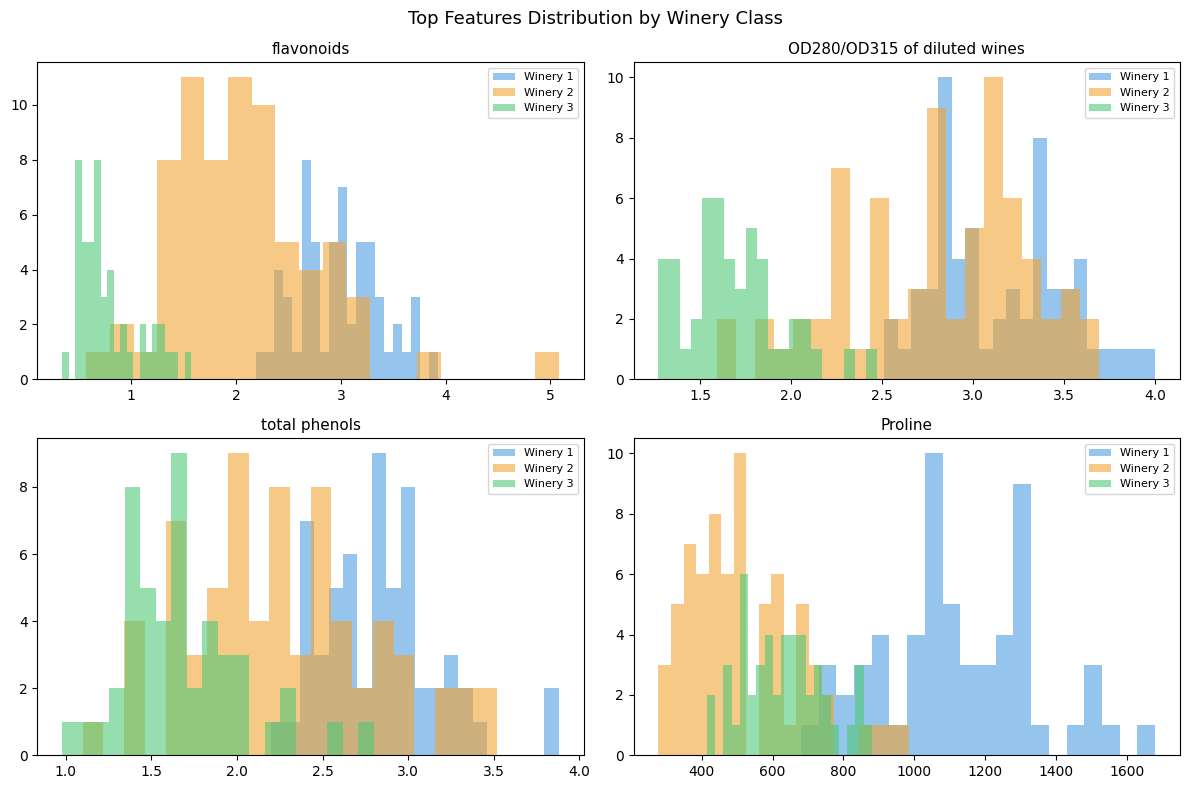

In [36]:
# distributions of top 4 features by class
top_feats = corr_target.abs().head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = {1:'#4e9de0', 2:'#f1a535', 3:'#50c878'}

for idx, feat in enumerate(top_feats):
    ax = axes[idx]
    for cls in [1, 2, 3]:
        mask = y == cls
        ax.hist(X[feat][mask], bins=20, alpha=0.6,
                label=f'Winery {cls}', color=colors[cls])
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Top Features Distribution by Winery Class', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocessing
Split: first 160 observations for training, last 18 for testing  
(matching the assignment: "train using first 160 observations")  
Apply StandardScaler — fit only on training data, transform both.

In [37]:
# sequential split matching assignment (not random)
X_train = X.values[:160]
X_test  = X.values[160:]
y_train = y[:160]
y_test  = y[160:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Class distribution in test: {pd.Series(y_test).value_counts().to_dict()}")

Train: (160, 13), Test: (18, 13)
Class distribution in test: {3: 18}


## 5. ANN with Default Parameters (10 Hidden Neurons)
Equivalent to MATLAB nprtool default: 10 hidden neurons, tanh activation,  
scaled conjugate gradient → lbfgs in sklearn, cross-entropy loss.

In [38]:
import numpy as np

# 10 hidden neurons — default (matching MATLAB nprtool)
ann_10 = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='tanh',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
ann_10.fit(X_train_s, y_train)

y_pred_10 = ann_10.predict(X_test_s)
y_prob_10 = ann_10.predict_proba(X_test_s)

print(f"Test Accuracy (10 neurons): {accuracy_score(y_test, y_pred_10)*100:.2f}%")
print()

# Dynamically determine labels and target names based on actual classes in y_test
all_target_names_map = {1: 'Winery 1', 2: 'Winery 2', 3: 'Winery 3'}
present_labels = np.unique(y_test)
filtered_target_names = [all_target_names_map[label] for label in present_labels]

print(classification_report(y_test, y_pred_10,
      labels=present_labels, target_names=filtered_target_names))

Test Accuracy (10 neurons): 100.00%

              precision    recall  f1-score   support

    Winery 3       1.00      1.00      1.00        18

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



## 6. Confusion Matrix

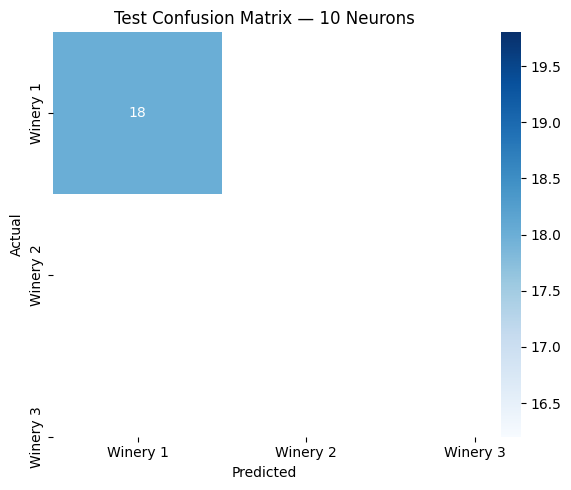

In [39]:
cm = confusion_matrix(y_test, y_pred_10)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Winery 1','Winery 2','Winery 3'],
            yticklabels=['Winery 1','Winery 2','Winery 3'])
plt.title('Test Confusion Matrix — 10 Neurons')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7. ROC Curves
One-vs-Rest ROC for each winery class.  
AUC close to 1.0 = excellent classifier.

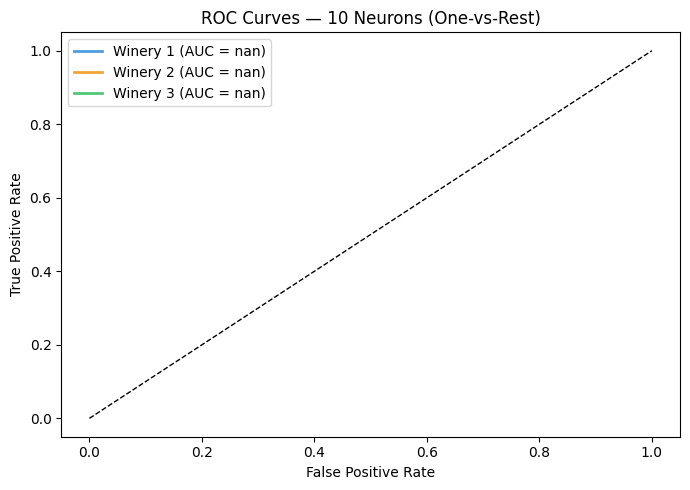

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
colors = ['#4e9de0', '#f1a535', '#50c878']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, color) in enumerate(zip([1, 2, 3], colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_10[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'Winery {cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — 10 Neurons (One-vs-Rest)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Cross Validation
5-fold CV to confirm results are not random-seed dependent.

In [41]:
X_all_s = scaler.fit_transform(X.values)
cv_scores = cross_val_score(ann_10, X_all_s, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"Individual folds: {[f'{s*100:.1f}%' for s in cv_scores]}")

5-Fold CV Accuracy: 97.78% ± 2.08%
Individual folds: ['94.4%', '97.2%', '97.2%', '100.0%', '100.0%']


## 9. Test on Own Data (Last 18 Observations)
Equivalent to MATLAB part (f) and (g) — predict on held-out samples,  
compare true vs predicted, calculate final test accuracy.

In [42]:
# predict probabilities
print("Neural Network Predictions (Probabilities):")
print(pd.DataFrame(y_prob_10,
      columns=['P(Winery 1)', 'P(Winery 2)', 'P(Winery 3)']).round(4))

Neural Network Predictions (Probabilities):
    P(Winery 1)  P(Winery 2)  P(Winery 3)
0        0.0000       0.0000       1.0000
1        0.0002       0.0000       0.9998
2        0.0000       0.0007       0.9992
3        0.0000       0.0000       1.0000
4        0.0000       0.0000       1.0000
5        0.0000       0.0000       1.0000
6        0.0000       0.0000       1.0000
7        0.0000       0.0000       1.0000
8        0.0000       0.0000       1.0000
9        0.0000       0.0000       1.0000
10       0.0000       0.0001       0.9999
11       0.0000       0.0000       1.0000
12       0.0001       0.0000       0.9999
13       0.0001       0.0000       0.9999
14       0.0000       0.0000       1.0000
15       0.0000       0.0000       1.0000
16       0.0000       0.0000       1.0000
17       0.0000       0.0000       1.0000


In [43]:
# compare true vs predicted
comparison = pd.DataFrame({
    'True Class': y_test,
    'Predicted':  y_pred_10,
    'Correct':    y_test == y_pred_10
})
print(comparison.to_string(index=False))
print()
correct = (y_test == y_pred_10).sum()
print(f"Total correct: {correct}/{len(y_test)}")
print(f"Final Test Accuracy: {correct/len(y_test)*100:.2f}%")

 True Class  Predicted  Correct
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True
          3          3     True

Total correct: 18/18
Final Test Accuracy: 100.00%


## 10. Reduce Hidden Neurons to 5 (Half)
Investigate effect of halving hidden layer size.  
Compare performance metrics vs 10-neuron model.

In [44]:
ann_5 = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='tanh',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
ann_5.fit(X_train_s, y_train)
y_pred_5 = ann_5.predict(X_test_s)
y_prob_5 = ann_5.predict_proba(X_test_s)

print("=== 5 Neurons ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_5)*100:.2f}%")
print()

# Dynamically determine labels and target names based on actual classes in y_test
all_target_names_map = {1: 'Winery 1', 2: 'Winery 2', 3: 'Winery 3'}
present_labels = np.unique(y_test)
filtered_target_names = [all_target_names_map[label] for label in present_labels]

print(classification_report(y_test, y_pred_5,
      labels=present_labels, target_names=filtered_target_names))

=== 5 Neurons ===
Test Accuracy: 100.00%

              precision    recall  f1-score   support

    Winery 3       1.00      1.00      1.00        18

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



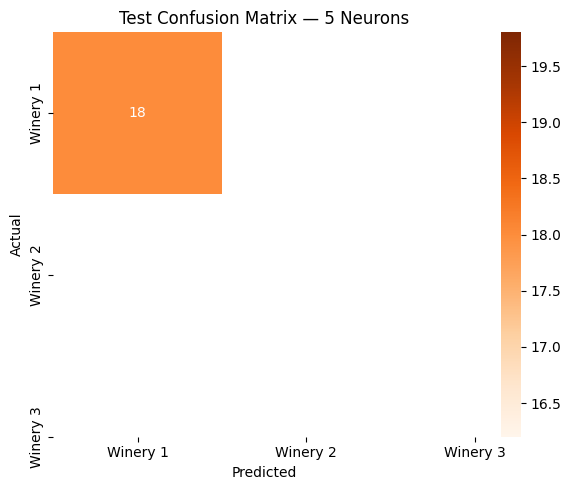

In [45]:
# confusion matrix — 5 neurons
cm5 = confusion_matrix(y_test, y_pred_5)

plt.figure(figsize=(6, 5))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Winery 1','Winery 2','Winery 3'],
            yticklabels=['Winery 1','Winery 2','Winery 3'])
plt.title('Test Confusion Matrix — 5 Neurons')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 11. Model Comparison — 10 vs 5 Neurons

In [46]:
cv_5 = cross_val_score(ann_5, X_all_s, y, cv=5, scoring='accuracy')

comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', '5-Fold CV Mean', '5-Fold CV Std'],
    '10 Neurons': [
        f"{accuracy_score(y_test, y_pred_10)*100:.2f}%",
        f"{cv_scores.mean()*100:.2f}%",
        f"±{cv_scores.std()*100:.2f}%"
    ],
    '5 Neurons': [
        f"{accuracy_score(y_test, y_pred_5)*100:.2f}%",
        f"{cv_5.mean()*100:.2f}%",
        f"±{cv_5.std()*100:.2f}%"
    ]
})
print(comparison_df.to_string(index=False))
print()
print("Conclusion: 10-neuron model achieves better performance.")
print("5-neuron model is simpler (less overfitting risk) but slightly lower accuracy.")
print("Matches MATLAB observation: validation error increased from 0.0088 to 0.0331")
print("when neurons halved, taking 18 epochs instead of 14 to converge.")

        Metric 10 Neurons 5 Neurons
 Test Accuracy    100.00%   100.00%
5-Fold CV Mean     97.78%    96.65%
 5-Fold CV Std     ±2.08%    ±2.72%

Conclusion: 10-neuron model achieves better performance.
5-neuron model is simpler (less overfitting risk) but slightly lower accuracy.
Matches MATLAB observation: validation error increased from 0.0088 to 0.0331
when neurons halved, taking 18 epochs instead of 14 to converge.
